# Imports + Load Data

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("../data/processed/cleaned_fake_news.csv")

X = df["clean_text"]
y = df["label"]

# Split + TF-IDF + Train Model

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

In [4]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_vec, y_train, cv=5, scoring="f1_macro"
)
print(f"5-fold CV F1 (macro): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

5-fold CV F1 (macro): 0.9878 +/- 0.0010


# Evaluation Metrics

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9893303064699206
Precision: 0.9931657848324515
Recall: 0.9862084063047285
F1-score: 0.9896748681898067

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4242
           1       0.99      0.99      0.99      4568

    accuracy                           0.99      8810
   macro avg       0.99      0.99      0.99      8810
weighted avg       0.99      0.99      0.99      8810



# Confusion Matrix + Explainability

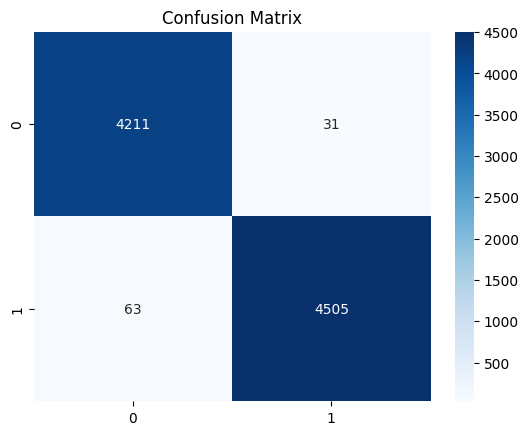

('Fake', ['breaking', 'shocking', 'news', 'government', 'scandal'])


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Explainability: top-N words by |TF-IDF_value * model_coefficient|
features = tfidf.get_feature_names_out()
weights = model.coef_[0]

def explain(text, top_n=10):
    vec = tfidf.transform([text])
    pred = model.predict(vec)[0]
    label = "Fake" if pred == 1 else "Real"

    feature_indices = vec.nonzero()[1]
    contributions = [
        (features[i], float(weights[i] * vec[0, i]))
        for i in feature_indices
    ]
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    important_words = [word for word, _ in contributions[:top_n]]

    return label, important_words

sample = "Breaking news: shocking discovery in government scandal"
print(explain(sample))

# SAVE LOGISTIC MODEL

In [7]:
import joblib
import os
import json
import datetime

os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(model, "../outputs/models/logistic_model.pkl")
joblib.dump(tfidf, "../outputs/models/tfidf_vectorizer.pkl")

metadata = {
    "trained_at": datetime.datetime.now().isoformat(),
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "f1_macro": float(f1_score(y_test, y_pred, average="macro")),
    "params": {"max_features": 5000, "ngram_range": "(1,2)", "class_weight": "balanced"}
}
with open("../outputs/models/logistic_model_meta.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("TF-IDF + Logistic Regression saved")

TF-IDF + Logistic Regression saved
